In [2]:
conda install pandas matplotlib seaborn numpy

Retrieving notices: ...working... done
Solving environment: done


==> WARNING: A newer version of conda exists. <==
  current version: 23.9.0
  latest version: 24.3.0

Please update conda by running

    $ conda update -n base -c conda-forge conda

Or to minimize the number of packages updated during conda update use

     conda install conda=24.3.0



# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.


In [1]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Reading In and Checking Data
eggnog_COG_category_df = pd.read_csv('out.emapper.annotations_modified', header=4, sep='\t', usecols=['#query', 'COG_category'])

eggnog_COG_category_df_non_null = eggnog_COG_category_df.dropna(subset=['COG_category','#query'])

# Filter rows where 'COG_category' is exactly one uppercase letter
cog_letters = eggnog_COG_category_df_non_null['COG_category'].apply(lambda x: len(x) == 1 and x.isupper())

# The result is a boolean series, so we use it to filter eggnog_COG_category_df_non_null
df_single_letter_COG_category = eggnog_COG_category_df_non_null[cog_letters]
print("\nSingle Letter COG Category Data Frame\n",df_single_letter_COG_category)

# Read in tsv file
context_df = pd.read_csv('Coarse_OrthoGroup_Contexts.Without_Last_Column.tsv', sep='\t', usecols=['Context entropy score', 'OG'])

print("\nTSV file Data Frame\n",context_df.head())

# Merge filtered data frame with corresponding ortholog groups 
merged_df = pd.merge(df_single_letter_COG_category, context_df, left_on='#query', right_on='OG', how='inner')

print("\Merged Data Frame\n",merged_df.head())

# Specifically identify the orthologous genes with the highest and lowest context entropy scores
top_10_genes_context_entropy = merged_df.nlargest(10, 'Context entropy score')
bottom_10_genes_context_entropy = merged_df.nsmallest(10, 'Context entropy score')
print("\nTOP 10\n", top_10_genes_context_entropy)
print("\nBOTTOM 10\n", bottom_10_genes_context_entropy)

         #query COG_category
0     OG0002476            Q
1     OG0003244            S
3     OG0000817            H
4     OG0004555            C
5     OG0001370            D
...         ...          ...
5747  OG0007066            I
5748  OG0007068            E
5749  OG0007327            V
5750  OG0007350            H
5751  OG0005570            K

[4610 rows x 2 columns]
          OG  Context entropy score
0  OG0000000                   6.95
1  OG0000001                   5.53
2  OG0000002                   6.84
3  OG0000003                   5.53
4  OG0000004                   6.46
      #query COG_category         OG  Context entropy score
0  OG0002476            Q  OG0002476                   4.67
1  OG0003244            S  OG0003244                   2.85
2  OG0000817            H  OG0000817                   3.46
3  OG0004555            C  OG0004555                   3.68
4  OG0001370            D  OG0001370                   3.16

TOP 10
          #query COG_category         OG  C

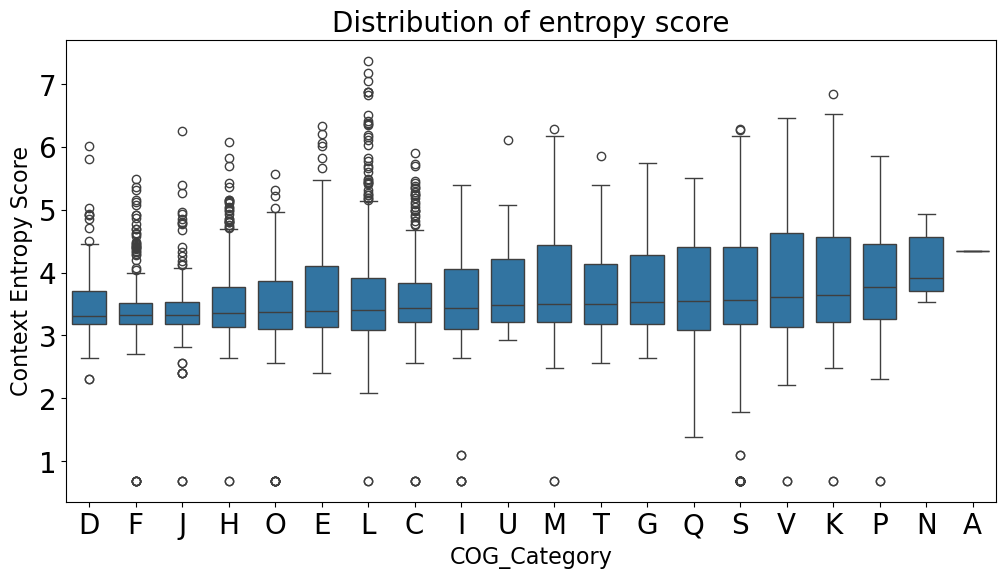

In [9]:
# Filtering and Processing Data for Visualization
# Calculate median values for 'Context variability score' for each 'COG_category'
medians = merged_df.groupby('COG_category')['Context entropy score'].median().sort_values()

# Create a list of 'COG_category' names ordered by the median value
ordered_categories = medians.index.tolist()

# Using seaborn to create a box plot
plt.figure(figsize=(12, 6))  # Adjusting the figure size for better visibility
sns.boxplot(data = merged_df, y='Context entropy score', x='COG_category', order = ordered_categories, gap=.1)

plt.title("Distribution of entropy score", fontsize = 20)
plt.xlabel("COG_Category", fontsize=16)
plt.ylabel("Context Entropy Score", fontsize=16)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)


# Save the plot to a file
plt.savefig('Distribution_Entropy_Score.png', dpi=300)

plt.show()

plt.close()
